In [1]:
from copy import deepcopy

import matplotlib.pyplot as plt
from matplotlib.image import imread
from mpl_toolkits import mplot3d
from matplotlib import gridspec
from PIL import Image
import io
import os
from urllib.request import urlopen
from skimage.segmentation import mark_boundaries

from tqdm import tqdm
import numpy as np
import requests
from scipy.stats import norm
import torch

from sklearn.metrics import classification_report
from torch.utils.tensorboard import SummaryWriter
from torchinfo import summary
from torchvision import datasets, transforms

2026-03-16 19:20:38.415142: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [2]:
%load_ext tensorboard

In [ ]:
%tensorboard --logdir liner/100

Reusing TensorBoard on port 6006 (pid 63765), started 0:04:29 ago. (Use '!kill 63765' to kill it.)

### Возьмём функции обучения с ноутбука первого семинара

In [5]:
def train_epoch(train_generator, model, loss_function, optimizer, callback = None):
    """
    Проходимся один раз по датасету бачированому и обучаемся на каждом батче
    """
    epoch_loss = 0
    total = 0
    for it, (batch_of_x, batch_of_y) in enumerate(train_generator):
        batch_loss = train_on_batch(model, batch_of_x, batch_of_y, optimizer, loss_function)
        
        if callback is not None:
            with torch.no_grad():
                callback(model, batch_loss)
            
        epoch_loss += batch_loss * len(batch_of_x)
        total += len(batch_of_x)
    
    return epoch_loss / total

In [6]:
def trainer(count_of_epoch, 
            batch_size, 
            dataset,
            model, 
            loss_function,
            optimizer,
            lr = 0.001,
            callback = None):
    """
    1) создаём оптимизатор
    2) проводим обучение count_of_epoch - количество эпох
    """
    optima = optimizer(model.parameters(), lr=lr)
    
    iterations = tqdm(range(count_of_epoch), desc='epoch')
    iterations.set_postfix({'train epoch loss': np.nan})
    for it in iterations:
        batch_generator = tqdm(
            torch.utils.data.DataLoader(dataset=dataset, batch_size=batch_size, shuffle=True), 
            leave=False, total=len(dataset) // batch_size + (len(dataset) % batch_size> 0))
        
        epoch_loss = train_epoch(train_generator=batch_generator, 
                    model=model, 
                    loss_function=loss_function, 
                    optimizer=optima, 
                    callback=callback)
        
        iterations.set_postfix({'train epoch loss': epoch_loss})

In [7]:
digit_size = (28, 28)

In [8]:
def train_on_batch(model, x_batch, y_batch, optimizer, loss_function):
    model.train()
    optimizer.zero_grad()
    
    output = model(x_batch.to(model.device))
    
    loss = loss_function(output, y_batch.to(model.device))
    loss.backward()

    optimizer.step()
    return loss.cpu().item()

In [ ]:
class callback():
    def __init__(self, writer, dataset, loss_function, delimeter = 100, batch_size=64):
        self.step = 0
        self.writer = writer
        self.delimeter = delimeter
        self.loss_function = loss_function
        self.batch_size = batch_size

        self.dataset = dataset

    def forward(self, model, loss):
        self.step += 1
        self.writer.add_scalar('LOSS/train', loss, self.step)
        
        if self.step % self.delimeter == 0:
            
            batch_generator = torch.utils.data.DataLoader(dataset = self.dataset, 
                                                          batch_size=self.batch_size, shuffle=True)
            
            pred = []
            real = []
            test_loss = 0
            model.eval()

            num_mistakes = 0
            fig_mistakes = plt.figure(figsize=(40, 40 / 10 * 2)) # будет 20 неправильно распознаных изображения показано
            gs_mistakes = gridspec.GridSpec(2, 10)


            num_examples = 0
            fig_examples = plt.figure(figsize=(40, 40 / 10 * 2)) # будет 20 неправильно распознаных изображения показано
            gs_examples = gridspec.GridSpec(2, 10)

            for it, (x_batch, y_batch) in enumerate(batch_generator):
                x_batch = x_batch.to(model.device)
                y_batch = y_batch.to(model.device)

                output = model(x_batch)

                test_loss += self.loss_function(output, y_batch).cpu().item() * len(x_batch)

                if num_mistakes < 20: # выводим только первые 20 ошибок
                    pred = torch.argmax(output, dim=-1).cpu().numpy().tolist()
                    real = y_batch.cpu().numpy().tolist()

                    idx_mistakes = np.where(np.array(pred) != np.array(real))[0]
                    j = 0

                    while num_mistakes < 20 and j < len(idx_mistakes):
                        ax = fig_mistakes.add_subplot(gs_mistakes[num_mistakes])
                        ax.imshow(x_batch[idx_mistakes[j]].cpu().view(*digit_size).numpy(),
                                cmap='Greys_r', interpolation='lanczos')
                        ax.axis('off')
                        ax.set_title(f'Вреный-{real[idx_mistakes[j]]}, Предсказаный-{pred[idx_mistakes[j]]}')

                        num_mistakes += 1
                        j += 1

                if num_examples < 20: # выводим только первые 20 примеров
                    pred = torch.argmax(output, dim=-1).cpu().numpy().tolist()
                    real = y_batch.cpu().numpy().tolist()
                    j = 0

                    while num_examples < 20 and j < len(x_batch):
                        ax = fig_examples.add_subplot(gs_examples[num_examples])
                        ax.imshow(x_batch[j].cpu().view(*digit_size).numpy(),
                                cmap='Greys_r', interpolation='lanczos')
                        ax.axis('off')
                        ax.set_title(f'Вреный-{real[j]}, Предсказаный-{pred[j]}')

                        num_examples += 1
                        j += 1
            
            test_loss /= len(self.dataset)
            
            self.writer.add_scalar('LOSS/test', test_loss, self.step)
                    
            self.writer.add_figure('VISUAL/errors', fig_mistakes, self.step)
            self.writer.add_figure('VISUAL/examples', fig_examples, self.step)
          
    def __call__(self, model, loss):
        return self.forward(model, loss)

### Загрузим и преобразуем датасет EMNIST-letters

In [10]:
preprocess = transforms.Compose([transforms.ToTensor(), 
                                 torch.FloatTensor])

In [11]:
EMNIST_train = datasets.EMNIST('./emnist', 'letters', train=True, download=True, 
                             transform=preprocess, target_transform=lambda x: x - 1)

EMNIST_test = datasets.EMNIST('./emnist', 'letters', train=False, download=True,
                            transform=preprocess, target_transform=lambda x: x - 1)

100%|██████████| 562M/562M [00:55<00:00, 10.1MB/s] 


Отобразим некоторые изображение из датасета

In [12]:
for x_batch, y_batch in torch.utils.data.DataLoader(dataset=EMNIST_train, batch_size=64, shuffle=True):
    pass

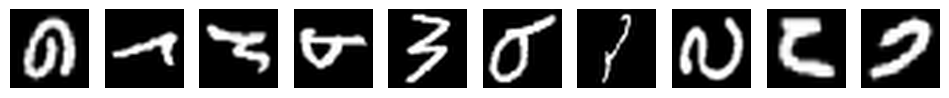

In [13]:
x = x_batch[-10:]
plt.figure(figsize=(12, 12 / 10 * (x.shape[0] // 10 + 1)))
for i in range(x.shape[0]):
    plt.subplot(x.shape[0] // 10 + 1, 10, i + 1)
    plt.imshow(x.data[i].view(*digit_size).numpy(), cmap='Greys_r', interpolation='lanczos')
    plt.axis('off')
        
plt.show()

### Эксперимент 1:

**Описание:**
1) Возьмём кодировщик предоставленный в семинаре
2) Добавим к нему линейный слов чтоб привести к 26 выходам (для классификации 26 классов)
3) Попробуем убрать BatchNorm2d и посмотрим что будет

**Что мы ожидаем увидить по теории (CNN1 vs CNN2)**:
1) CNN1 - меньше вреия обучения
2) CNN1 - обучение должно быть более стабильным
3) CNN1 - лучше обобщяемая способность

In [14]:
class CNN1(torch.nn.Module):
    @property
    def device(self):
        return next(self.parameters()).device

    def __init__(self, d):
        super(type(self), self).__init__()
        self.d = d

        self.layers = torch.nn.Sequential()
        self.layers.add_module('conv1', torch.nn.Conv2d(1, 6, kernel_size = 5))
        self.layers.add_module('bnorm1', torch.nn.BatchNorm2d(6))
        self.layers.add_module('relu1', torch.nn.ReLU())
        self.layers.add_module('pool1', torch.nn.MaxPool2d(kernel_size = 2))
        
        self.layers.add_module('conv2', torch.nn.Conv2d(6, 16, kernel_size = 5))
        self.layers.add_module('bnorm2', torch.nn.BatchNorm2d(16))
        self.layers.add_module('relu2', torch.nn.ReLU())
        self.layers.add_module('pool2', torch.nn.MaxPool2d(kernel_size = 2))
        
        self.layers.add_module('conv3', torch.nn.Conv2d(16, self.d, kernel_size = 3))
        self.layers.add_module('relu3', torch.nn.ReLU())
        self.layers.add_module('pool3', torch.nn.MaxPool2d(kernel_size = 2))

        self.layers.add_module('flatten', torch.nn.Flatten())

        self.layers.add_module('linear1', torch.nn.Linear(self.d, 26))
    def forward(self, input):
        return self.layers(input)

In [15]:
loss_function = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam

d=32
model = CNN1(d)
model.to(device)

writer = SummaryWriter(log_dir = 'model-cnn-1/{}'.format(d))
call = callback(writer, EMNIST_test, loss_function, delimeter = 100)

trainer(count_of_epoch=5, 
        batch_size=64, 
        dataset=EMNIST_train,
        model=model, 
        loss_function=loss_function,
        optimizer = optimizer,
        lr = 0.001,
        callback = call)

epoch: 100%|██████████| 5/5 [08:16<00:00, 99.30s/it, train epoch loss=0.256] 


In [16]:
class CNN2(torch.nn.Module):
    @property
    def device(self):
        return next(self.parameters()).device

    def __init__(self, d):
        super(type(self), self).__init__()
        self.d = d

        self.layers = torch.nn.Sequential()
        self.layers.add_module('conv1', torch.nn.Conv2d(1, 6, kernel_size = 5))
        self.layers.add_module('relu1', torch.nn.ReLU())
        self.layers.add_module('pool1', torch.nn.MaxPool2d(kernel_size = 2))
        
        self.layers.add_module('conv2', torch.nn.Conv2d(6, 16, kernel_size = 5))
        self.layers.add_module('relu2', torch.nn.ReLU())
        self.layers.add_module('pool2', torch.nn.MaxPool2d(kernel_size = 2))
        
        self.layers.add_module('conv3', torch.nn.Conv2d(16, self.d, kernel_size = 3))
        self.layers.add_module('relu3', torch.nn.ReLU())
        self.layers.add_module('pool3', torch.nn.MaxPool2d(kernel_size = 2))

        self.layers.add_module('flatten', torch.nn.Flatten())

        self.layers.add_module('linear1', torch.nn.Linear(self.d, 26))
    def forward(self, input):
        return self.layers(input)

In [17]:
loss_function = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam

d=32
model = CNN2(d)
model.to(device)

writer = SummaryWriter(log_dir = 'model-cnn-2/{}'.format(d))
call = callback(writer, EMNIST_test, loss_function, delimeter = 100)

trainer(count_of_epoch=5, 
        batch_size=64, 
        dataset=EMNIST_train,
        model=model, 
        loss_function=loss_function,
        optimizer = optimizer,
        lr = 0.001,
        callback = call)

epoch: 100%|██████████| 5/5 [08:31<00:00, 102.21s/it, train epoch loss=0.346]


In [ ]:
%tensorboard --logdir model-cnn-1/32

In [ ]:
%tensorboard --logdir model-cnn-2/32

**Вывод**  
Что явно подтвердилось
1) Обучилось быстрее
2) Выбило лучший скор на тестовой но на train хуже )
Что не ясно
1) От чего-то на train с batchnorm больший разброс!

### Эксперимент 2:

**Описание:**
1) Возьмём кодировщик предоставленный в семинаре
2) Добавим к нему линейный слов чтоб привести к 26 выходам (для классификации 26 классов)
3) Попробуем добавить Dropout увеличить (по сравнению с CNN1 CNN2 количество линейных слаёв) (убираем bnorm2 - от чего-то их не используют вместе)

**Что мы ожидаем увидить по теории (CNN1 vs CNN2)**:
1) больше параметров - если не словим переобучение будет лучше работать
3) лучше обобщяемая способность

In [20]:
class CNN3(torch.nn.Module):
    @property
    def device(self):
        return next(self.parameters()).device

    def __init__(self, d):
        super(type(self), self).__init__()
        self.d = d

        self.layers = torch.nn.Sequential()
        self.layers.add_module('conv1', torch.nn.Conv2d(1, 6, kernel_size = 5))
        self.layers.add_module('relu1', torch.nn.ReLU())
        self.layers.add_module('dropout1', torch.nn.Dropout2d(p=0.3))
        self.layers.add_module('pool1', torch.nn.MaxPool2d(kernel_size = 2))
        
        self.layers.add_module('conv2', torch.nn.Conv2d(6, 16, kernel_size = 5))
        self.layers.add_module('relu2', torch.nn.ReLU())
        self.layers.add_module('dropout2', torch.nn.Dropout2d(p=0.2))
        self.layers.add_module('pool2', torch.nn.MaxPool2d(kernel_size = 2))
        
        self.layers.add_module('conv3', torch.nn.Conv2d(16, self.d, kernel_size = 3))
        self.layers.add_module('relu3', torch.nn.ReLU())
        self.layers.add_module('pool3', torch.nn.MaxPool2d(kernel_size = 2))

        self.layers.add_module('flatten', torch.nn.Flatten())

        self.layers.add_module('linear1', torch.nn.Linear(self.d, int(self.d / 2)))
        self.layers.add_module('linear2', torch.nn.Linear(int(self.d / 2), 26))
    def forward(self, input):
        return self.layers(input)

In [21]:
loss_function = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam

d=64
model = CNN3(d)
model.to(device)

writer = SummaryWriter(log_dir = 'model-cnn-3/{}'.format(d))
call = callback(writer, EMNIST_test, loss_function, delimeter = 100)

trainer(count_of_epoch=5, 
        batch_size=64, 
        dataset=EMNIST_train,
        model=model, 
        loss_function=loss_function,
        optimizer = optimizer,
        lr = 0.001,
        callback = call)

epoch: 100%|██████████| 5/5 [08:38<00:00, 103.71s/it, train epoch loss=0.468]


In [ ]:
%tensorboard --logdir model-cnn-3/64

**Вывод**
1) Обучилось быстрее
2) Качество хуже от чего точно не ясно

### Эксперимент 3:

**Описание:**
Основная идея - чем глубже тем лучше построим более глубокую модель

In [23]:
class CNN4(torch.nn.Module):
    @property
    def device(self):
        return next(self.parameters()).device

    def __init__(self, d):
        super(type(self), self).__init__()
        self.d = d

        self.layers = torch.nn.Sequential()
        self.layers.add_module('conv1', torch.nn.Conv2d(1, 6, kernel_size = 7, padding=3))
        self.layers.add_module('bnorm1', torch.nn.BatchNorm2d(6))
        self.layers.add_module('relu1', torch.nn.ReLU())
        self.layers.add_module('pool1', torch.nn.MaxPool2d(kernel_size = 2))
        
        self.layers.add_module('conv2', torch.nn.Conv2d(6, 12, kernel_size = 5, padding=2))
        self.layers.add_module('bnorm2', torch.nn.BatchNorm2d(12))
        self.layers.add_module('relu2', torch.nn.ReLU())
        self.layers.add_module('pool2', torch.nn.MaxPool2d(kernel_size = 2))
        
        self.layers.add_module('conv3', torch.nn.Conv2d(12, 18, kernel_size = 3, padding=1))
        self.layers.add_module('bnorm3', torch.nn.BatchNorm2d(18))
        self.layers.add_module('relu3', torch.nn.ReLU())
        self.layers.add_module('pool3', torch.nn.MaxPool2d(kernel_size = 2, padding=1))

        self.layers.add_module('conv4', torch.nn.Conv2d(18, 24, kernel_size = 3, padding=1))
        self.layers.add_module('bnorm3', torch.nn.BatchNorm2d(18))
        self.layers.add_module('relu4', torch.nn.ReLU())
        self.layers.add_module('pool4', torch.nn.MaxPool2d(kernel_size = 2))

        self.layers.add_module('conv5', torch.nn.Conv2d(24, self.d, kernel_size = 2))
        self.layers.add_module('relu5', torch.nn.ReLU())

        self.layers.add_module('flatten', torch.nn.Flatten())

        self.layers.add_module('linear1', torch.nn.Linear(self.d, self.d // 2))
        self.layers.add_module('linear2', torch.nn.Linear(self.d // 2, self.d // 4))
        self.layers.add_module('linear3', torch.nn.Linear(self.d // 4, 26))
    def forward(self, input):
        return self.layers(input)

In [24]:
loss_function = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam

d=128
model = CNN4(d)
model.to(device)

writer = SummaryWriter(log_dir = 'model-cnn-4/{}'.format(d))
call = callback(writer, EMNIST_test, loss_function, delimeter = 100)

trainer(count_of_epoch=7, 
        batch_size=64, 
        dataset=EMNIST_train,
        model=model, 
        loss_function=loss_function,
        optimizer = optimizer,
        lr = 0.001,
        callback = call)

epoch: 100%|██████████| 7/7 [12:28<00:00, 106.88s/it, train epoch loss=0.188]


In [ ]:
%tensorboard --logdir model-cnn-4/128

**Вывод**
Модель дала лучшее качество. Однако стоит логировать модели по эпохам чтоб выбирать лучшею (под конец обучения обобщающая способность ухудшилась).

### Эксперимент 4:

**Описание:**  
Попробуем разные размеры ядер (экстримально большие и экстремально маленькие)

**Что мы ожидаем увидить по теории**  
Ядро это как бы область видимсти если оно очень маленькое нейросеть не 'ухватит' общею структуру  
Если ядро большое нейросеть будет смотреть на очень отдолённые пиксели 'как на один'

Ожидаеться что лучше всего будут работать ядра средних размеров

In [26]:
class CNN5(torch.nn.Module):
    @property
    def device(self):
        return next(self.parameters()).device

    def __init__(self, d):
        super(type(self), self).__init__()
        self.d = d

        self.layers = torch.nn.Sequential()
        self.layers.add_module('conv1', torch.nn.Conv2d(1, 6, kernel_size = 2))
        self.layers.add_module('bnorm1', torch.nn.BatchNorm2d(6))
        self.layers.add_module('relu1', torch.nn.ReLU())
        self.layers.add_module('pool1', torch.nn.MaxPool2d(kernel_size = 2))
        
        self.layers.add_module('conv2', torch.nn.Conv2d(6, 16, kernel_size = 2))
        self.layers.add_module('bnorm2', torch.nn.BatchNorm2d(16))
        self.layers.add_module('relu2', torch.nn.ReLU())
        self.layers.add_module('pool2', torch.nn.MaxPool2d(kernel_size = 2))
        
        self.layers.add_module('conv3', torch.nn.Conv2d(16, self.d, kernel_size = 2))
        self.layers.add_module('relu3', torch.nn.ReLU())
        self.layers.add_module('pool3', torch.nn.MaxPool2d(kernel_size = 2))

        self.layers.add_module('flatten', torch.nn.Flatten())

        self.layers.add_module('linear1', torch.nn.Linear(4 * self.d, 26))
    def forward(self, input):
        return self.layers(input)

In [27]:
loss_function = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam

d=16
model = CNN5(16)
model.to(device)

writer = SummaryWriter(log_dir = 'model-cnn-5/{}'.format(d))
call = callback(writer, EMNIST_test, loss_function, delimeter = 100)

trainer(count_of_epoch=5, 
        batch_size=64, 
        dataset=EMNIST_train,
        model=model, 
        loss_function=loss_function,
        optimizer = optimizer,
        lr = 0.001,
        callback = call)

epoch: 100%|██████████| 5/5 [08:38<00:00, 103.62s/it, train epoch loss=0.456]


In [ ]:
%tensorboard --logdir model-cnn-5/16

In [29]:
class CNN6(torch.nn.Module):
    @property
    def device(self):
        return next(self.parameters()).device

    def __init__(self, d):
        super(type(self), self).__init__()
        self.d = d

        self.layers = torch.nn.Sequential()
        self.layers.add_module('conv1', torch.nn.Conv2d(1, 6, kernel_size = 9, padding=4))
        self.layers.add_module('bnorm1', torch.nn.BatchNorm2d(6))
        self.layers.add_module('relu1', torch.nn.ReLU())
        self.layers.add_module('pool1', torch.nn.MaxPool2d(kernel_size = 4))
        
        self.layers.add_module('conv2', torch.nn.Conv2d(6, self.d, kernel_size = 9, padding=4))
        self.layers.add_module('relu2', torch.nn.ReLU())
        self.layers.add_module('pool2', torch.nn.MaxPool2d(kernel_size = 4))

        self.layers.add_module('flatten', torch.nn.Flatten())

        self.layers.add_module('linear1', torch.nn.Linear(self.d, 26))
    def forward(self, input):
        return self.layers(input)

In [30]:
loss_function = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam

d=64
model = CNN6(64)
model.to(device)

writer = SummaryWriter(log_dir = 'model-cnn-6/{}'.format(d))
call = callback(writer, EMNIST_test, loss_function, delimeter = 100)

trainer(count_of_epoch=5, 
        batch_size=64, 
        dataset=EMNIST_train,
        model=model, 
        loss_function=loss_function,
        optimizer = optimizer,
        lr = 0.001,
        callback = call)

epoch: 100%|██████████| 5/5 [08:33<00:00, 102.75s/it, train epoch loss=0.208]


In [ ]:
%tensorboard --logdir model-cnn-6/64

**Вывод** Мы построили две модели. С очень маленькими ядрами для свярточных слоёв и пулингом и очень большими. Как и ожидалось модель с маленькими ядрами дала плохой результат а вот вторая модель показала собя не плохо (на уровне CNN1) однако если сделать свёртку экстремально большой (14 условно) думаю будет плохо работать.

### Эксперимент 5:

**Описание:**  
Создадим ещё 3 архитектуры просто покрутим всевазможные параметры попробует выбить max скор

In [32]:
class CNN7(torch.nn.Module):
    @property
    def device(self):
        return next(self.parameters()).device

    def __init__(self, d):
        super(type(self), self).__init__()
        self.d = d

        self.layers = torch.nn.Sequential()

        self.layers.add_module('conv1', torch.nn.Conv2d(1, 16, kernel_size=3, padding=1))
        self.layers.add_module('bnorm1', torch.nn.BatchNorm2d(16))
        self.layers.add_module('relu1', torch.nn.ReLU())
        self.layers.add_module('pool1', torch.nn.MaxPool2d(2))

        self.layers.add_module('conv2', torch.nn.Conv2d(16, 32, kernel_size=3, padding=1))
        self.layers.add_module('bnorm2', torch.nn.BatchNorm2d(32))
        self.layers.add_module('relu2', torch.nn.ReLU())
        self.layers.add_module('pool2', torch.nn.MaxPool2d(2))

        self.layers.add_module('conv3', torch.nn.Conv2d(32, 64, kernel_size=3, padding=1))
        self.layers.add_module('bnorm3', torch.nn.BatchNorm2d(64))
        self.layers.add_module('relu3', torch.nn.ReLU())

        self.layers.add_module('conv4', torch.nn.Conv2d(64, 128, kernel_size=3, padding=1))
        self.layers.add_module('bnorm4', torch.nn.BatchNorm2d(128))
        self.layers.add_module('relu4', torch.nn.ReLU())
        self.layers.add_module('pool3', torch.nn.MaxPool2d(2))

        self.layers.add_module('conv5', torch.nn.Conv2d(128, self.d, kernel_size=3, padding=1))
        self.layers.add_module('bnorm5', torch.nn.BatchNorm2d(self.d))
        self.layers.add_module('relu5', torch.nn.ReLU())
        self.layers.add_module('pool4', torch.nn.MaxPool2d(2))

        self.layers.add_module('flatten', torch.nn.Flatten())
        self.layers.add_module('dropout', torch.nn.Dropout(0.5))
        self.layers.add_module('linear', torch.nn.Linear(self.d, 26))

    def forward(self, input):
        return self.layers(input)

In [33]:
loss_function = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam

d=64
model = CNN7(64)
model.to(device)

writer = SummaryWriter(log_dir = 'model-cnn-7/{}'.format(d))
call = callback(writer, EMNIST_test, loss_function, delimeter = 100)

trainer(count_of_epoch=10, 
        batch_size=64, 
        dataset=EMNIST_train,
        model=model, 
        loss_function=loss_function,
        optimizer = optimizer,
        lr = 0.001,
        callback = call)

epoch: 100%|██████████| 10/10 [18:17<00:00, 109.71s/it, train epoch loss=0.151]


In [ ]:
%tensorboard --logdir model-cnn-7/64

In [35]:
class CNN8(torch.nn.Module):
    @property
    def device(self):
        return next(self.parameters()).device

    def __init__(self, d):
        super(type(self), self).__init__()
        self.d = d

        self.layers = torch.nn.Sequential()

        self.layers.add_module('conv1', torch.nn.Conv2d(1, 32, kernel_size=7))
        self.layers.add_module('bnorm1', torch.nn.BatchNorm2d(32))
        self.layers.add_module('relu1', torch.nn.ReLU())
        self.layers.add_module('pool1', torch.nn.MaxPool2d(2))

        self.layers.add_module('conv2', torch.nn.Conv2d(32, 64, kernel_size=5))
        self.layers.add_module('bnorm2', torch.nn.BatchNorm2d(64))
        self.layers.add_module('relu2', torch.nn.ReLU())
        self.layers.add_module('pool2', torch.nn.MaxPool2d(2))

        self.layers.add_module('conv3', torch.nn.Conv2d(64, self.d, kernel_size=3))
        self.layers.add_module('bnorm3', torch.nn.BatchNorm2d(self.d))
        self.layers.add_module('relu3', torch.nn.ReLU())

        self.layers.add_module('flatten', torch.nn.Flatten())
        self.layers.add_module('linear', torch.nn.Linear(self.d, 26))

    def forward(self, input):
        return self.layers(input)

In [36]:
loss_function = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam

d=64
model = CNN8(64)
model.to(device)

writer = SummaryWriter(log_dir = 'model-cnn-8/{}'.format(d))
call = callback(writer, EMNIST_test, loss_function, delimeter = 100)

trainer(count_of_epoch=10, 
        batch_size=64, 
        dataset=EMNIST_train,
        model=model, 
        loss_function=loss_function,
        optimizer = optimizer,
        lr = 0.001,
        callback = call)

epoch:   0%|          | 0/10 [00:00<?, ?it/s, train epoch loss=nan]

epoch: 100%|██████████| 10/10 [18:32<00:00, 111.21s/it, train epoch loss=0.109]


In [ ]:
%tensorboard --logdir model-cnn-8/64

In [38]:
class CNN9(torch.nn.Module):
    @property
    def device(self):
        return next(self.parameters()).device

    def __init__(self, d):
        super(type(self), self).__init__()
        self.d = d

        self.layers = torch.nn.Sequential()

        self.layers.add_module('conv1', torch.nn.Conv2d(1, 32, kernel_size=7))
        self.layers.add_module('bnorm1', torch.nn.BatchNorm2d(32))
        self.layers.add_module('relu1', torch.nn.ReLU())
        self.layers.add_module('pool1', torch.nn.MaxPool2d(2))

        self.layers.add_module('conv2', torch.nn.Conv2d(32, 64, kernel_size=5))
        self.layers.add_module('bnorm2', torch.nn.BatchNorm2d(64))
        self.layers.add_module('relu2', torch.nn.ReLU())
        self.layers.add_module('pool2', torch.nn.MaxPool2d(2))

        self.layers.add_module('conv3', torch.nn.Conv2d(64, self.d, kernel_size=3))
        self.layers.add_module('bnorm3', torch.nn.BatchNorm2d(self.d))
        self.layers.add_module('relu3', torch.nn.ReLU())

        self.layers.add_module('flatten', torch.nn.Flatten())
        self.layers.add_module('linear', torch.nn.Linear(self.d, 26))

    def forward(self, input):
        return self.layers(input)

In [39]:
loss_function = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam

d=64
model = CNN9(64)
model.to(device)

writer = SummaryWriter(log_dir = 'model-cnn-9/{}'.format(d))
call = callback(writer, EMNIST_test, loss_function, delimeter = 100)

trainer(count_of_epoch=10, 
        batch_size=64, 
        dataset=EMNIST_train,
        model=model, 
        loss_function=loss_function,
        optimizer = optimizer,
        lr = 0.001,
        callback = call)

epoch: 100%|██████████| 10/10 [18:00<00:00, 108.07s/it, train epoch loss=0.107]


In [ ]:
%tensorboard --logdir model-cnn-9/64

**Вывод** Мы построили 3 модели попытались порутить всевозможные параметры вышло что - 7мая модель лучше всех скор выбила (оно и понятна она грубокая)